# Imputation of numerical columns

### Data Gathering and splitting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('E:/Dataset/titanic_toy.csv')

In [3]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [4]:
df.sample(2)

,Age,Fare,Family,Survived
19,NaN,7.225,0,1
467,56.0,26.550,0,0


In [5]:
x = df.iloc[:,:3]
y = df.iloc[:,-1]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=34)

In [8]:
x_train.shape, x_test.shape

((712, 3), (179, 3))

In [9]:
x_train.isnull().mean()

Age       0.196629
Fare      0.046348
Family    0.000000
dtype: float64

## Filling value with <b>mean</b>, and <b>median</b>

### Using pandas

In [10]:
age_mean = x_train['Age'].mean()
age_median = x_train['Age'].median()

fare_mean = x_train['Fare'].mean()
fare_median = x_train['Fare'].median()

In [11]:
x_train['age_mean'] = x_train['Age'].fillna(age_mean)
x_train['age_median'] = x_train['Age'].fillna(age_median)

x_train['fare_mean'] = x_train['Fare'].fillna(fare_mean)
x_train['fare_median'] = x_train['Fare'].fillna(fare_median)

In [12]:
x_train.sample(4)

,Age,Fare,Family,age_mean,age_median,fare_mean,fare_median
54,65.0,61.9792,1,65.0,65.0,61.9792,61.9792
691,4.0,13.4167,1,4.0,4.0,13.4167,13.4167
700,18.0,227.5250,1,18.0,18.0,227.5250,227.5250
857,51.0,26.5500,0,51.0,51.0,26.5500,26.5500


### Analyzing data after imputation

In [13]:
print('Original age variance: ', x_train['Age'].var())
print('Age variance after mean imputation: ', x_train['age_mean'].var())
print('Age variance after median imputation: ', x_train['age_median'].var())
print()
print('Original fare variance: ', x_train['Fare'].var())
print('Fare variance after mean imputation: ', x_train['fare_mean'].var())
print('Fare variance after median imputation: ', x_train['fare_median'].var())

Original age variance:  216.5069799566457
Age variance after mean imputation:  173.8755071100488
Age variance after median imputation:  174.40542600546826

Original fare variance:  2402.2434240659686
Fare variance after mean imputation:  2290.7468938350585
Fare variance after median imputation:  2303.063352930416


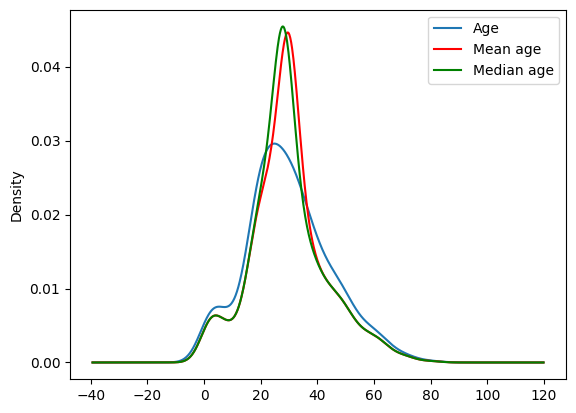

In [14]:
x_train['Age'].plot(kind='kde', label="Age")
x_train['age_mean'].plot(kind='kde', color='red', label='Mean age')
x_train['age_median'].plot(kind='kde', color='green', label='Median age')
plt.legend()

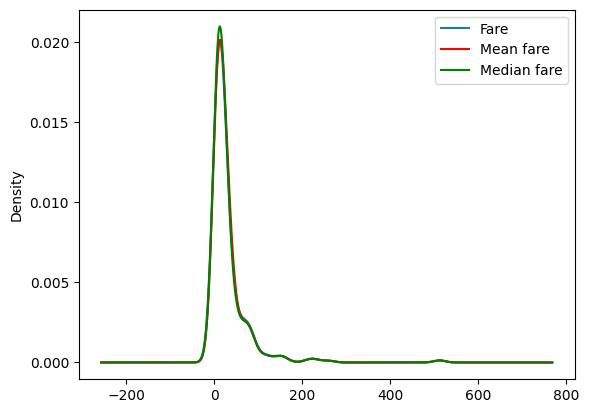

In [15]:
x_train['Fare'].plot(kind='kde', label="Fare")
x_train['fare_mean'].plot(kind='kde', color='red', label='Mean fare')
x_train['fare_median'].plot(kind='kde', color='green', label='Median fare')
plt.legend()

In [16]:
x_train.cov()

,Age,Fare,Family,age_mean,age_median,fare_mean,fare_median
Age,216.506980,72.599765,-6.773694,216.506980,216.506980,68.715853,66.422497
Fare,72.599765,2402.243424,13.877249,57.871315,61.330628,2402.243424,2402.243424
Family,-6.773694,13.877249,2.441329,-5.439915,-5.370222,13.233157,13.356232
age_mean,216.506980,57.871315,-5.439915,173.875507,173.875507,55.185305,53.343524
age_median,216.506980,61.330628,-5.370222,173.875507,174.405426,58.484058,56.578348
fare_mean,68.715853,2402.243424,13.233157,55.185305,58.484058,2290.746894,2290.746894
fare_median,66.422497,2402.243424,13.356232,53.343524,56.578348,2290.746894,2303.063353


In [17]:
x_train.corr()

,Age,Fare,Family,age_mean,age_median,fare_mean,fare_median
Age,1.000000,0.093609,-0.319493,1.000000,1.000000,0.091230,0.087907
Fare,0.093609,1.000000,0.178683,0.089295,0.094511,1.000000,1.000000
Family,-0.319493,0.178683,1.000000,-0.264034,-0.260255,0.176955,0.178122
age_mean,1.000000,0.089295,-0.264034,1.000000,0.998480,0.087441,0.084297
age_median,1.000000,0.094511,-0.260255,0.998480,1.000000,0.092527,0.089272
fare_mean,0.091230,1.000000,0.176955,0.087441,0.092527,1.000000,0.997322
fare_median,0.087907,1.000000,0.178122,0.084297,0.089272,0.997322,1.000000


<Axes: >

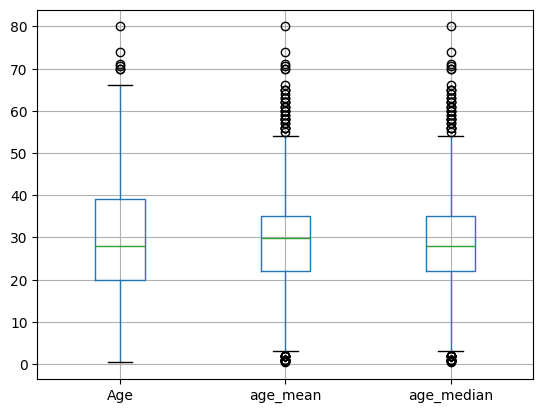

In [18]:
x_train[['Age','age_mean','age_median']].boxplot()

<Axes: >

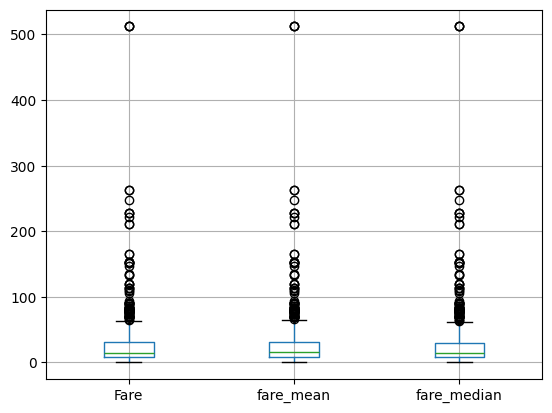

In [19]:
x_train[['Fare','fare_mean','fare_median']].boxplot()

### Using sklearn

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)

In [21]:
from sklearn.impute import SimpleImputer

In [22]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [23]:
from sklearn.compose import ColumnTransformer

In [24]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')

In [25]:
trf.fit(x_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [26]:
trf.named_transformers_['imputer1'].statistics_

array([28.])

In [27]:
trf.named_transformers_['imputer2'].statistics_

array([31.21688175])

In [28]:
x_train_trf = trf.transform(x_train)
x_test_trf = trf.transform(x_test)

In [29]:
x_train_trf

array([[19.    , 30.    ,  0.    ],
       [34.    , 32.5   ,  2.    ],
       [ 2.    , 12.2875,  1.    ],
       ...,
       [35.    , 26.2875,  0.    ],
       [32.    , 15.85  ,  1.    ],
       [31.    , 50.4958,  0.    ]], shape=(712, 3))

## Filling value with <b>Arbitrary value</b>(a single value)

In [30]:
df.sample(3)

,Age,Fare,Family,Survived
220,16.0,8.0500,0,1
886,27.0,13.0000,0,0
478,22.0,7.5208,0,0


In [31]:
x.sample(2)

,Age,Fare,Family
237,8.0,26.25,2
235,NaN,7.55,0


In [32]:
y.sample(2)

238    0
478    0
Name: Survived, dtype: int64

In [33]:
x_train.sample(2)

,Age,Fare,Family
10,4.0,16.700,2
79,30.0,12.475,0


### Using Pandas

In [34]:
x_train['age_99'] = x_train['Age'].fillna(99)
x_train['age_minus1'] = x_train['Age'].fillna(-1)

x_train['fare_999'] = x_train['Fare'].fillna(999)
x_train['fare_minus1'] = x_train['Fare'].fillna(-1)

In [35]:
x_train.sample(2)

,Age,Fare,Family,age_99,age_minus1,fare_999,fare_minus1
871,47.0,NaN,2,47.0,47.0,999.00,-1.00
45,NaN,8.05,0,99.0,-1.0,8.05,8.05


### Analyzing after value imputation

In [36]:
print("Variance of age column before imputation:", x_train['Age'].var())
print("Variance of age column after imputing 99:", x_train['age_99'].var())
print("Variance of age column after imputing -1:", x_train['age_minus1'].var())
print()
print("Variance of fare column before imputation:", x_train['Fare'].var())
print("Variance of fare column after imputing 999:", x_train['fare_999'].var())
print("Variance of fare column after imputing -1:", x_train['fare_minus1'].var())

Variance of age column before imputation: 217.29286946463318
Variance of age column after imputing 99: 952.0425033929081
Variance of age column after imputing -1: 330.68124610376196

Variance of fare column before imputation: 1788.8025768614632
Variance of fare column after imputing 999: 49079.191183341194
Variance of fare column after imputing -1: 1745.7107846307292


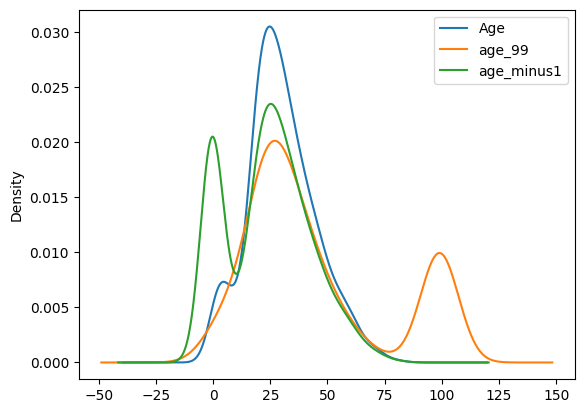

In [46]:
fig = plt.figure()
ax = fig.add_subplot(111)
x_train['Age'].plot(kind='kde', ax=ax)
x_train['age_99'].plot(kind='kde', ax=ax)
x_train['age_minus1'].plot(kind='kde', ax=ax)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

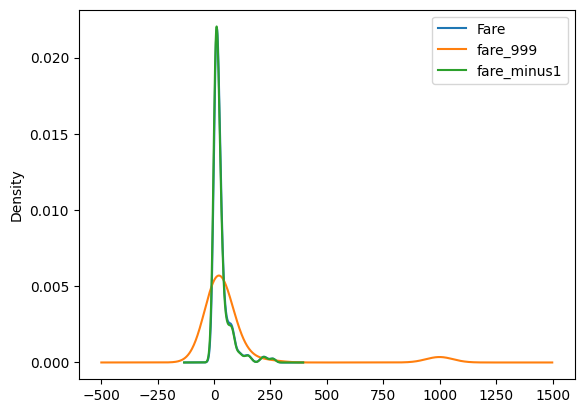

In [52]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Fare'].plot(kind='kde', ax=ax)
x_train['fare_999'].plot(kind='kde', ax=ax)
x_train['fare_minus1'].plot(kind='kde', ax=ax)

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels)

In [53]:
x_train.cov()

,Age,Fare,Family,age_99,age_minus1,fare_999,fare_minus1
Age,217.292869,60.920128,-6.212178,217.292869,217.292869,56.548720,57.496250
Fare,60.920128,1788.802577,16.426650,-70.330632,101.551111,1788.802577,1788.802577
Family,-6.212178,16.426650,2.511842,-7.093948,-3.951713,9.817322,15.739508
age_99,217.292869,-70.330632,-7.093948,952.042503,-178.963589,-240.469128,-60.782819
age_minus1,217.292869,101.551111,-3.951713,-178.963589,330.681246,173.428665,93.550190
fare_999,56.548720,1788.802577,9.817322,-240.469128,173.428665,49079.191183,115.749077
fare_minus1,57.496250,1788.802577,15.739508,-60.782819,93.550190,115.749077,1745.710785


In [54]:
x_train.corr()

,Age,Fare,Family,age_99,age_minus1,fare_999,fare_minus1
Age,1.000000,0.093042,-0.293860,1.000000,1.000000,0.016864,0.089435
Fare,0.093042,1.000000,0.241608,-0.053637,0.131434,1.000000,1.000000
Family,-0.293860,0.241608,1.000000,-0.145065,-0.137115,0.027961,0.237689
age_99,1.000000,-0.053637,-0.145065,1.000000,-0.318957,-0.035179,-0.047148
age_minus1,1.000000,0.131434,-0.137115,-0.318957,1.000000,0.043049,0.123127
fare_999,0.016864,1.000000,0.027961,-0.035179,0.043049,1.000000,0.012505
fare_minus1,0.089435,1.000000,0.237689,-0.047148,0.123127,0.012505,1.000000


### Using Sklearn

In [98]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=4)

In [101]:
imp1 = SimpleImputer(strategy='constant', fill_value=99)
imp2 = SimpleImputer(strategy='constant', fill_value=999)

In [105]:
tf = ColumnTransformer([
    ('imp1', imp1, ['Age']),
    ('imp2', imp2, ['Fare'])
], remainder='passthrough')

In [106]:
tf.fit(x_train)

,transformers,"[('imp1', ...), ('imp2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [112]:
tf.named_transformers_['imp1'].statistics_

array([99.])

In [113]:
trf.named_transformers_['imp2'].statistics_

array([999.])

In [114]:
x_train_trf = trf.transform(x_train)
x_test_trf = trf.transform(x_test)

In [115]:
x_train_trf

array([[99.    ,  7.8958,  0.    ],
       [60.    , 39.    ,  2.    ],
       [36.    , 15.55  ,  1.    ],
       ...,
       [31.    , 10.5   ,  0.    ],
       [56.    , 30.6958,  0.    ],
       [32.5   , 30.0708,  1.    ]], shape=(712, 3))